<a href="https://colab.research.google.com/github/yrainjiang/Eye-Detection-AI/blob/main/Eye_Bias_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import zipfile, os

uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/eye_dataset')

print(os.listdir('/content/eye_dataset'))

Saving archive.zip to archive (2).zip
['Eye dataset', 'dataset']


In [ ]:
import os

for root, dirs, files in os.walk('/content/eye_dataset/dataset'):
    print(root)

/content/eye_dataset/dataset
/content/eye_dataset/dataset/train
/content/eye_dataset/dataset/train/Open_Eyes
/content/eye_dataset/dataset/train/Closed_Eyes
/content/eye_dataset/dataset/test
/content/eye_dataset/dataset/test/Open_Eyes
/content/eye_dataset/dataset/test/Closed_Eyes


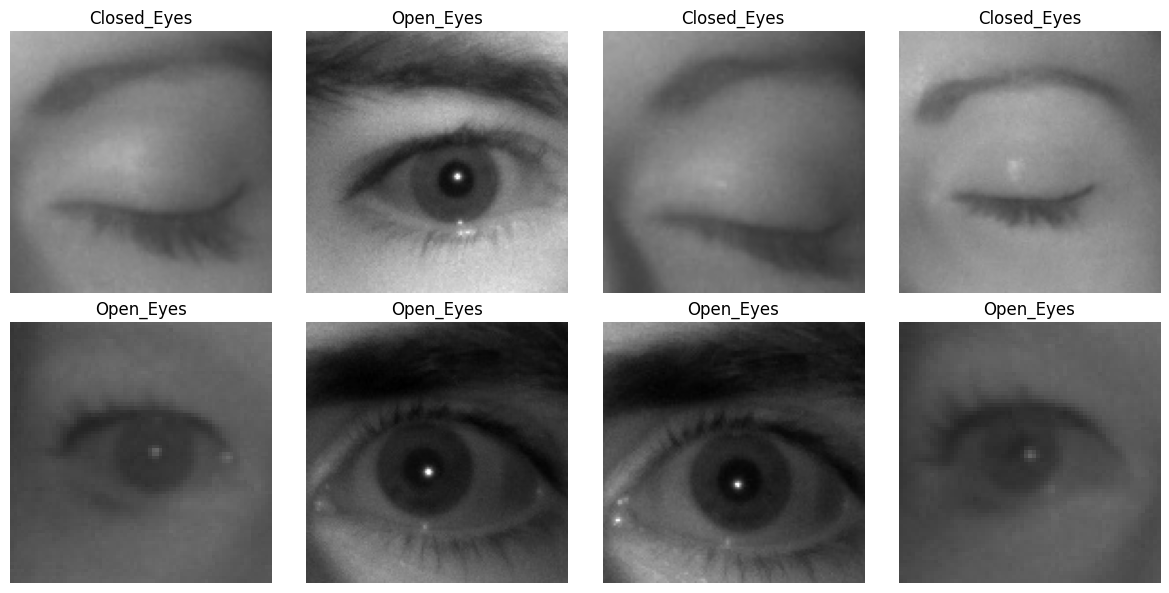

In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import os

BASE = "/content/eye_dataset/dataset"

top_level_dirs = [d for d in os.listdir(BASE)
                  if os.path.isdir(os.path.join(BASE, d))]

fig, axes = plt.subplots(2,4, figsize=(12,6))

for ax in axes.ravel():
    current_top_dir = random.choice(top_level_dirs)
    top_dir_path = os.path.join(BASE, current_top_dir)

    sub_dirs = [d for d in os.listdir(top_dir_path)
                if os.path.isdir(os.path.join(top_dir_path, d))]

    current_class_label = random.choice(sub_dirs)
    class_dir_path = os.path.join(top_dir_path, current_class_label)

    image_files = [f for f in os.listdir(class_dir_path)
                   if os.path.isfile(os.path.join(class_dir_path, f))]

    img_name = random.choice(image_files)

    path = os.path.join(class_dir_path, img_name)

    ax.imshow(Image.open(path).convert('RGB'))
    ax.set_title(current_class_label)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

IMG = (128, 128)
BATCH = 32
BASE = "/content/eye_dataset/dataset"
#Training generator
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1])

val_gen = ImageDataGenerator(rescale=1./255)



#Training data
train = train_gen.flow_from_directory(
    "/content/eye_dataset/dataset/train",
    target_size=IMG,
    batch_size=BATCH,
    class_mode='binary',
    shuffle=True
)

#Validation Data
val = val_gen.flow_from_directory(
    "/content/eye_dataset/dataset/test",
    target_size=IMG,
    batch_size=BATCH,
    class_mode='binary',
    shuffle=False
)

#Model
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

#Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#Train
history = model.fit(
    train,
    validation_data=val,
    epochs = 10
)

#Save model
model.save('/content/eye_open_closed_model.keras')

Found 3400 images belonging to 2 classes.
Found 600 images belonging to 2 classes.
Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 74s 656ms/step - accuracy: 0.8524 - loss: 0.3088 - val_accuracy: 0.9933 - val_loss: 0.0487
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 79s 650ms/step - accuracy: 0.9682 - loss: 0.0979 - val_accuracy: 0.9983 - val_loss: 0.0084
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 658ms/step - accuracy: 0.9818 - loss: 0.0623 - val_accuracy: 0.9983 - val_loss: 0.0027
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 73s 684ms/step - accuracy: 0.9897 - loss: 0.0335 - val_accuracy: 0.9983 - val_loss: 0.0042
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 655ms/step - accuracy: 0.9965 - loss: 0.0146 - val_accuracy: 0.9983 - val_loss: 0.0020
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 657ms/step - accuracy: 0.9932 - loss: 0.0225 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 69s 642ms/step - accuracy: 0.9950 - loss: 0.0137 - val_accuracy: 0.9983 - val_loss: 0.0022


In [ ]:
from google.colab import files

uploaded = files.upload()

test_image_path = list(uploaded.keys())[0]

Saving IMG_6763.JPG to IMG_6763.JPG


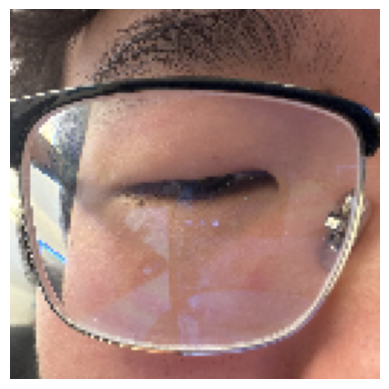

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Prediction value: 7.9504025e-06
AI thinks: CLOSED


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(test_image_path, target_size=(128,128))

plt.imshow(img)
plt.axis('off')
plt.show()

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

print("Prediction value:", prediction)

if prediction > 0.5:
    print("AI thinks: OPEN")
else:
    print("AI thinks: CLOSED")

In [ ]:
from google.colab import files

uploaded = files.upload()

test_image_path = list(uploaded.keys())[0]

Saving IMG_6762.jpg to IMG_6762 (1).jpg


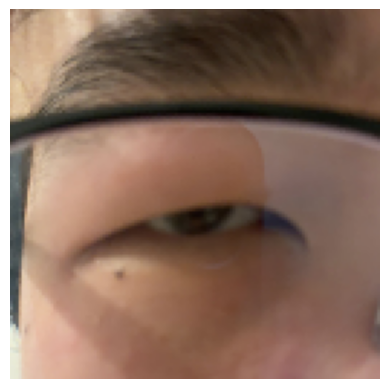

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Prediction value: 1.0
AI thinks: OPEN


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(test_image_path, target_size=(128,128))

plt.imshow(img)
plt.axis('off')
plt.show()

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

print("Prediction value:", prediction)

if prediction > 0.5:
    print("AI thinks: OPEN")
else:
    print("AI thinks: CLOSED")